# UK Employment and Mean Pay Analysis

**Contents**

| Section | What it does |
|---|---|
| 0. Setup | Imports, configuration, helper functions |
| 1. Load & clean | Reads both sheets, finds the real header row, fixes types once |
| 2. EDA | Figures 1–2, with each hypothesis tested against the numbers |
| 3. Data Preprocessing | Forward-fill missing values, z-score standardisation |
| 4. Supervised learning | Linear regression forecast of June 2025 mean pay, plus a backtest extension |
| 5. Unsupervised learning | K-means on Employees (col V) vs PAYE mean pay (col X) |
| 6. Summary | Every number is generated from the results above |

**To run:** put `COMP 1886 - Coursework Dataset.xlsx` next to this notebook and use *Run All*.
Figures are saved to `figures/`; the clustering CSV is saved as `Employees_PAYE.csv`.


## 0. Setup

In [1]:
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from openpyxl.utils import column_index_from_string
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, silhouette_score)
from sklearn.preprocessing import StandardScaler

# ---- Configuration (change things here, not deep inside the analysis) ------
DATA_FILE     = Path("COMP 1886 - Coursework Dataset.xlsx")
EMP_SHEET     = "Employees (Industry)"
PAY_SHEET     = "Mean Pay (industry)"
TEST_MONTH    = pd.Timestamp("2025-06-01")   # Month held out for forecasting
N_CLUSTER_OBS = 50                           # First n observations used for clustering
K_FINAL       = 3                            # Chosen number of clusters
RANDOM_STATE  = 42
FIG_DIR       = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.labelsize": 11,
})
thousands = FuncFormatter(lambda x, _: f"{x:,.0f}")


def finish(fig, filename):
    """Tidy layout, save to figures/, and show."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


def short(label, width=40):
    return textwrap.shorten(str(label), width=width, placeholder="…")

## 1. Load and clean

Both sheets have title rows above the real header. `load_sheet` finds the row that starts with
`Date`, uses it as the header, tidies the column names (some contain stray line breaks),
parses the dates and sorts chronologically. Numeric columns are converted **once** here, so later
cells don't need repeated `pd.to_numeric` calls.

In [2]:
def load_sheet(path, sheet):
    """Read a sheet whose real header row (starting with 'Date') sits below title rows."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    hits = raw.index[raw.iloc[:, 0].astype(str).str.strip().eq("Date")]
    if hits.empty:
        raise ValueError(f"No header row starting with 'Date' found in sheet '{sheet}'")
    header_row = hits[0]

    df = raw.iloc[header_row + 1:].copy()
    df.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in raw.iloc[header_row]]
    df = df.dropna(subset=["Date"])
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, format="mixed")
    return df.sort_values("Date").reset_index(drop=True)


emp = load_sheet(DATA_FILE, EMP_SHEET)
pay = load_sheet(DATA_FILE, PAY_SHEET)

# Numeric columns: everything except Date (Employees); Mean Pay also has two
# categorical columns (Excel columns B and C) that sit between Date and the data.
EMP_NUM = [c for c in emp.columns if c != "Date"]
PAY_NUM = list(pay.columns[3:])
emp[EMP_NUM] = emp[EMP_NUM].apply(pd.to_numeric, errors="coerce")
pay[PAY_NUM] = pay[PAY_NUM].apply(pd.to_numeric, errors="coerce")

# Sanity checks: chronological, roughly monthly, UK total in the last column
for name, df in [("Employees", emp), ("Mean pay", pay)]:
    gaps = df["Date"].diff().dt.days.dropna()
    print(f"{name:10s}: {len(df)} rows x {df.shape[1]} cols | "
          f"{df['Date'].min():%b %Y} to {df['Date'].max():%b %Y} | "
          f"monthly spacing: {bool(gaps.between(28, 31).all())}")
assert emp.columns[-1] == "UK" and pay.columns[-1] == "UK", "UK total should be the last column"

display(emp.head(3))
display(pay.head(3))

Employees : 133 rows x 22 cols | Jul 2014 to Jul 2025 | monthly spacing: True
Mean pay  : 132 rows x 24 cols | Jul 2014 to Jun 2025 | monthly spacing: True


,Date,"Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,Transportation and storage,Accommodation and food service activities,...,Real estate,"Professional, scientific and technical",Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK
0,2014-07-01,195597,59358,2337672,92821,155087,1079928,4283572,1166829,1787337,...,394011,1863203,2321467,1521915,2975889,3419006,528033,491769,93648,26893849
1,2014-08-01,194663,59607,2342156,92678,155203,1092236,4290019,1163634,1801181,...,395070,1863740,2316466,1510945,2901803,3433116,539577,490853,93999,26865396
2,2014-09-01,190243,59905,2363800,92225,155268,1099190,4298133,1171355,1790801,...,396368,1877156,2346129,1507823,2903446,3435981,539594,495431,94551,26945380


,Date,Was there any payroll error or Data Issue this month,"Majority of the payroll were contributed by people from region North East, North West or East Midlands","Agriculture, forestry and fishing",Mining and quarrying,Manufacturing,Energy production and supply,"Water supply, sewerage and waste",Construction,Wholesale and retail; repair of motor vehicles,...,Real estate,"Professional, scientific and technical",Administrative and support services,Public administration and defence; social security,Education,Health and social work,"Arts, entertainment and recreation",Other service activities,Households and Extraterritorial,UK
0,2014-07-01,yes,North East,0.0,4969.0,2531.0,3584.0,2543.0,2392,1627,...,2264,2865,1756,2409,1956,1932,1820,1545.0,1113.0,2151
1,2014-08-01,no,North East,1581.0,4793.0,2463.0,3455.0,2381.0,2373,1614,...,2158,2799,1742,2371,1978,1937,1806,1557.0,1148.0,2141
2,2014-09-01,yes,North West,1595.0,4866.0,2470.0,3364.0,2394.0,2399,1602,...,2149,2805,1752,2377,1973,1943,1788,1521.0,1093.0,2134


## 2. Exploratory Data Analysis

Each hypothesis is stated up front and then **checked against the data**, so the conclusions
printed below come from the numbers rather than being written in advance.

### Figure 1 – UK employees over time
**Hypothesis 1:** long-term upward trend, with a dip during COVID-19 in 2020.

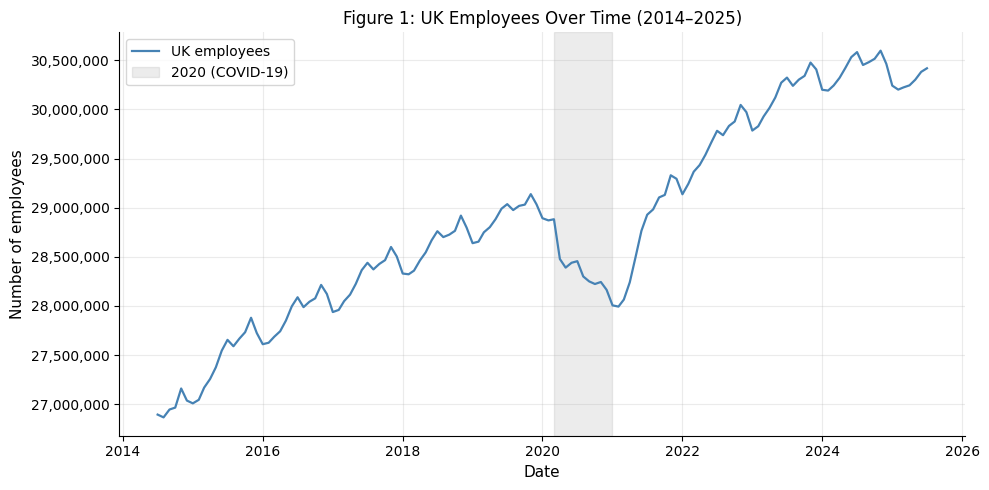

Overall change Jul 2014 -> Jul 2025: +13.1%
COVID trough (Dec 2020): -2.4% vs pre-COVID level
Back to pre-COVID level: Jul 2021
Hypothesis 1 supported: True


In [3]:
uk_emp = emp.set_index("Date")["UK"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(uk_emp.index, uk_emp, color="steelblue", lw=1.6, label="UK employees")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-12-31"),
           color="grey", alpha=0.15, label="2020 (COVID-19)")
ax.yaxis.set_major_formatter(thousands)
ax.set(title=f"Figure 1: UK Employees Over Time "
             f"({uk_emp.index.min().year}–{uk_emp.index.max().year})",
       xlabel="Date", ylabel="Number of employees")
ax.legend()
finish(fig, "figure1_employees.png")

# Evidence for Hypothesis 1
pre_covid   = uk_emp[:"2020-02-29"].iloc[-1]
covid_win   = uk_emp["2020-03-01":"2020-12-31"]
trough_date = covid_win.idxmin()
dip_pct     = covid_win.min() / pre_covid - 1
growth_pct  = uk_emp.iloc[-1] / uk_emp.iloc[0] - 1
after       = uk_emp[trough_date:]
recovered   = after[after >= pre_covid]
recovery    = recovered.index[0] if len(recovered) else None

print(f"Overall change {uk_emp.index[0]:%b %Y} -> {uk_emp.index[-1]:%b %Y}: {growth_pct:+.1%}")
print(f"COVID trough ({trough_date:%b %Y}): {dip_pct:+.1%} vs pre-COVID level")
print("Back to pre-COVID level:", f"{recovery:%b %Y}" if recovery is not None else "not within the data")
print("Hypothesis 1 supported:", bool(growth_pct > 0 and dip_pct < 0))

### Figure 2 – Mean pay: top 3 vs bottom 3 sectors
**Hypothesis 2:** high-paying sectors earn far more than low-paying ones, and the gap has widened since 2021.
"Households and Extraterritorial" is excluded from the ranking (set `EXCLUDE_PREFIX` to change this).

Top 3   : ['Finance and insurance', 'Mining and quarrying', 'Information and communication']
Bottom 3: ['Accommodation and food service activities', 'Agriculture, forestry and fishing', 'Other service activities']


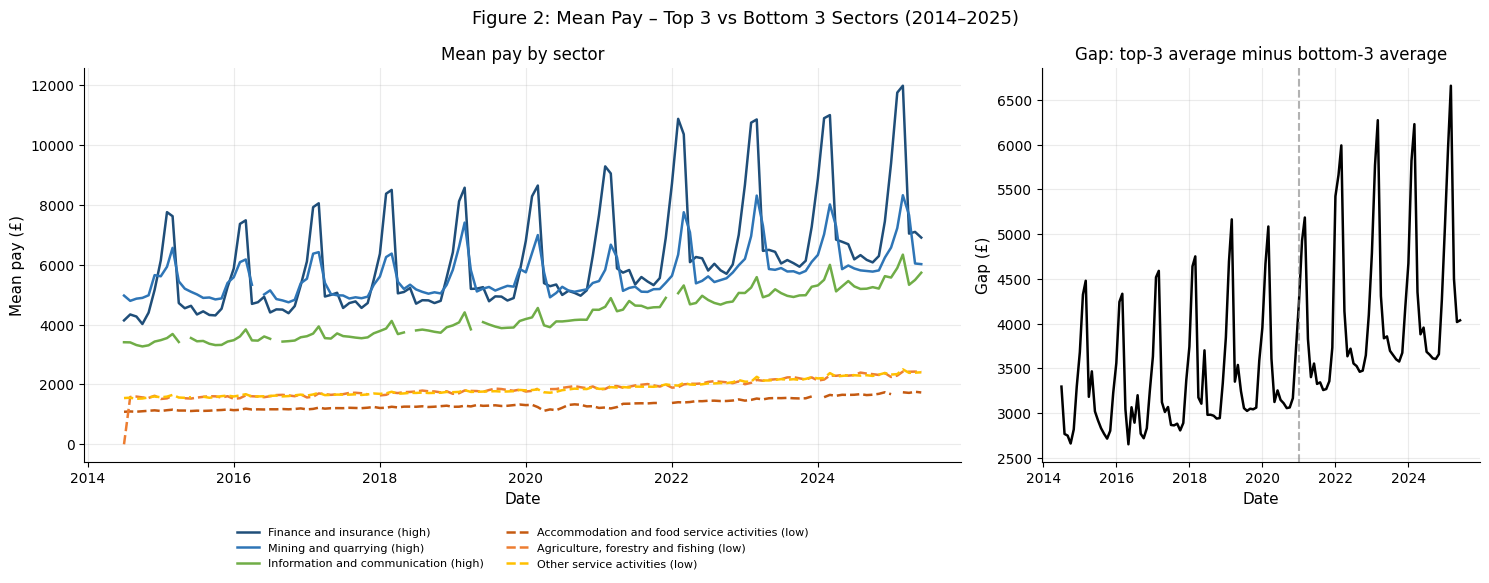

Average gap in 2021: £3,785   |   last 12 months: £4,396
Top-3 pay is 3.2x the bottom-3 pay on average
Hypothesis 2 (gap wider since 2021) supported: True


In [4]:
EXCLUDE_PREFIX = "Households"

pay_lvl = pay.set_index("Date")[PAY_NUM]          # raw levels, before any filling
SECTORS = [c for c in PAY_NUM if c != "UK"]

sector_means = pay_lvl[SECTORS].mean()
sector_means = sector_means[~sector_means.index.str.startswith(EXCLUDE_PREFIX)]
top3 = sector_means.nlargest(3).index.tolist()
bot3 = sector_means.nsmallest(3).index.tolist()
print("Top 3   :", top3)
print("Bottom 3:", bot3)

gap = pay_lvl[top3].mean(axis=1) - pay_lvl[bot3].mean(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})
for col, colour in zip(top3, ["#1f4e79", "#2e75b6", "#70ad47"]):
    ax1.plot(pay_lvl.index, pay_lvl[col], color=colour, lw=1.8, label=f"{short(col, 45)} (high)")
for col, colour in zip(bot3, ["#c55a11", "#ed7d31", "#ffc000"]):
    ax1.plot(pay_lvl.index, pay_lvl[col], color=colour, lw=1.8, ls="--", label=f"{short(col, 45)} (low)")
ax1.set(title="Mean pay by sector", xlabel="Date", ylabel="Mean pay (£)")
ax1.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)

ax2.plot(gap.index, gap, color="black", lw=1.8)
ax2.axvline(pd.Timestamp("2021-01-01"), color="grey", ls="--", alpha=0.6)
ax2.set(title="Gap: top-3 average minus bottom-3 average", xlabel="Date", ylabel="Gap (£)")

fig.suptitle(f"Figure 2: Mean Pay – Top 3 vs Bottom 3 Sectors "
             f"({pay_lvl.index.min().year}–{pay_lvl.index.max().year})", fontsize=13)
finish(fig, "figure2_sector_divergence.png")

# Evidence for Hypothesis 2
gap_2021, gap_latest = gap["2021"].mean(), gap.iloc[-12:].mean()
print(f"Average gap in 2021: £{gap_2021:,.0f}   |   last 12 months: £{gap_latest:,.0f}")
print(f"Top-3 pay is {pay_lvl[top3].mean(axis=1).mean() / pay_lvl[bot3].mean(axis=1).mean():.1f}x the bottom-3 pay on average")
print("Hypothesis 2 (gap wider since 2021) supported:", bool(gap_latest > gap_2021))

## 3. Data Preprocessing

### Technique 1 – Forward-fill missing values
Forward-fill carries the last observed value forward. It suits monthly pay/employment levels (they
change slowly) and, importantly for forecasting, it uses **only past information**. Linear interpolation
would use *future* values and leak information into the training data.

In [5]:
def n_missing(df, cols):
    return int(df[cols].isna().sum().sum())


missing_before = {"Employees (Industry)": n_missing(emp, EMP_NUM),
                  "Mean Pay (Industry)": n_missing(pay, PAY_NUM)}

emp_proc, pay_proc = emp.copy(), pay.copy()
emp_proc[EMP_NUM] = emp_proc[EMP_NUM].ffill()
pay_proc[PAY_NUM] = pay_proc[PAY_NUM].ffill()

missing_after = {"Employees (Industry)": n_missing(emp_proc, EMP_NUM),
                 "Mean Pay (Industry)": n_missing(pay_proc, PAY_NUM)}

table2 = pd.DataFrame({"Sheet": list(missing_before),
                       "Missing before": list(missing_before.values()),
                       "Missing after (ffill)": list(missing_after.values())})
print("Table 2: Missing value summary")
display(table2)

if any(missing_after.values()):
    print("Warning: some values are still missing (likely at the very start of a series).")

# Where were the gaps?
for label, df, cols in [("Employees", emp, EMP_NUM), ("Mean pay", pay, PAY_NUM)]:
    per_col = df[cols].isna().sum()
    per_col = per_col[per_col > 0]
    if len(per_col):
        print(f"\n{label}: columns with missing values")
        display(per_col.rename("missing").to_frame())

Table 2: Missing value summary


,Sheet,Missing before,Missing after (ffill)
0,Employees (Industry),0,0
1,Mean Pay (Industry),22,0



Mean pay: columns with missing values


,missing
"Agriculture, forestry and fishing",3
Mining and quarrying,1
Manufacturing,2
Energy production and supply,2
"Water supply, sewerage and waste",4
Accommodation and food service activities,3
Information and communication,5
Other service activities,1
Households and Extraterritorial,1


### Technique 2 – Z-score standardisation
Rescales each series to mean 0 and standard deviation 1 so that variables on different scales
(headcount vs £) can be compared and used together in distance-based methods such as K-means.
Demonstrated here on the two UK totals.

In [6]:
def zscore_table(series_by_label):
    rows = []
    for label, s in series_by_label.items():
        x = s.dropna().to_numpy().reshape(-1, 1)
        z = StandardScaler().fit_transform(x)
        rows.append({"Feature": label,
                     "Mean (before)": round(float(x.mean()), 2),
                     "Std dev (before)": round(float(x.std()), 2),
                     "Mean (after)": round(float(z.mean()), 4) + 0.0,
                     "Std dev (after)": round(float(z.std()), 4)})
    return pd.DataFrame(rows)


table3 = zscore_table({"UK Employees": emp_proc["UK"], "UK Mean Pay": pay_proc["UK"]})
print("Table 3: Standardisation results")
display(table3)

Table 3: Standardisation results


,Feature,Mean (before),Std dev (before),Mean (after),Std dev (after)
0,UK Employees,28849186.01,1031004.00,0.0,1.0
1,UK Mean Pay,2627.93,375.69,0.0,1.0


## 4. Supervised Learning: Linear Regression

**Brief:** remove Excel columns B and C from the Mean Pay sheet, transpose (rows = industries,
columns = dates), and predict June 2025 mean pay for each industry with linear regression.

Each industry gets its own model: mean pay regressed on *months since the start of the series*,
trained on every month **before** the test month.

In [7]:
pay_reduced = pay_proc.drop(columns=pay_proc.columns[[1, 2]])   # remove Excel columns B, C
pay_t = pay_reduced.set_index("Date").T                          # rows = industries, cols = dates
print("Transposed shape (industries x dates):", pay_t.shape)

TEST_DATE = pay_t.columns[pay_t.columns >= TEST_MONTH][0]        # first available date in the test month
ORIGIN    = pay_t.columns.min()


def months_since_origin(dates):
    d = pd.DatetimeIndex(dates)
    return ((d.year - ORIGIN.year) * 12 + (d.month - ORIGIN.month)).to_numpy().reshape(-1, 1)


def linear_forecast(series, target, window=None):
    """OLS trend on months before `target` (optionally only the last `window` months)."""
    train = series[series.index < target].dropna()
    if window:
        train = train.iloc[-window:]
    model = LinearRegression().fit(months_since_origin(train.index), train.to_numpy())
    return float(model.predict(months_since_origin([target]))[0])


def naive_forecast(series, target):
    """Baseline: repeat the last observed value."""
    return float(series[series.index < target].dropna().iloc[-1])

Transposed shape (industries x dates): (21, 132)


### 4.1 UK aggregate – single-month forecast

UK mean pay, Jun 2025
  Actual    : £3,291.00
  Predicted : £3,226.85
  Abs error : £64.15 (1.95% of actual)
  R² is undefined for one test observation, so MAE/RMSE both equal the absolute error.


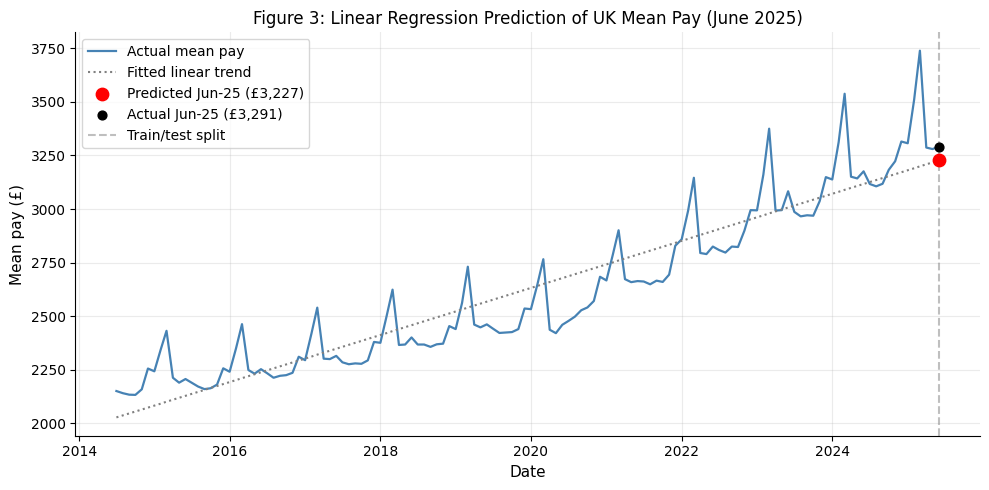

In [8]:
uk = pay_t.loc["UK"]
actual_uk = float(uk.loc[TEST_DATE])
pred_uk   = linear_forecast(uk, TEST_DATE)
abs_err_uk = abs(pred_uk - actual_uk)

print(f"UK mean pay, {TEST_DATE:%b %Y}")
print(f"  Actual    : £{actual_uk:,.2f}")
print(f"  Predicted : £{pred_uk:,.2f}")
print(f"  Abs error : £{abs_err_uk:,.2f} ({abs_err_uk / actual_uk:.2%} of actual)")
print("  R² is undefined for one test observation, so MAE/RMSE both equal the absolute error.")

# Figure 3
train_uk = uk[uk.index < TEST_DATE].dropna()
trend = LinearRegression().fit(months_since_origin(train_uk.index), train_uk.to_numpy())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(uk.index, uk, color="steelblue", lw=1.6, label="Actual mean pay")
ax.plot(uk.index, trend.predict(months_since_origin(uk.index)), color="grey", ls=":", lw=1.5,
        label="Fitted linear trend")
ax.scatter([TEST_DATE], [pred_uk], color="red", s=80, zorder=5,
           label=f"Predicted {TEST_DATE:%b-%y} (£{pred_uk:,.0f})")
ax.scatter([TEST_DATE], [actual_uk], color="black", s=40, zorder=5,
           label=f"Actual {TEST_DATE:%b-%y} (£{actual_uk:,.0f})")
ax.axvline(TEST_DATE, color="grey", ls="--", alpha=0.5, label="Train/test split")
ax.set(title=f"Figure 3: Linear Regression Prediction of UK Mean Pay ({TEST_DATE:%B %Y})",
       xlabel="Date", ylabel="Mean pay (£)")
ax.legend()
finish(fig, "figure3_regression.png")

### 4.2 All industries
The 21 series in the transposed table are the **20 industries plus the UK total**. The UK row is kept in
the table for reference but is left out of the industry-level averages.

In [9]:
rows = []
for name, s in pay_t.iterrows():
    actual, pred = float(s.loc[TEST_DATE]), linear_forecast(s, TEST_DATE)
    rows.append({"Industry": name, "Predicted": round(pred, 2), "Actual": round(actual, 2),
                 "Abs_Error": round(abs(pred - actual), 2),
                 "Pct_Error": round(100 * abs(pred - actual) / actual, 2)})
predictions_df = pd.DataFrame(rows)
sector_df = predictions_df[predictions_df["Industry"] != "UK"].reset_index(drop=True)

print(f"Predicted vs actual mean pay, {TEST_DATE:%B %Y}")
display(predictions_df)

mae_sectors  = mean_absolute_error(sector_df["Actual"], sector_df["Predicted"])
rmse_sectors = float(np.sqrt(mean_squared_error(sector_df["Actual"], sector_df["Predicted"])))
print(f"\nAcross the {len(sector_df)} industries:  MAE £{mae_sectors:,.2f}  |  RMSE £{rmse_sectors:,.2f}  "
      f"|  mean % error {sector_df['Pct_Error'].mean():.2f}%")

Predicted vs actual mean pay, June 2025


,Industry,Predicted,Actual,Abs_Error,Pct_Error
0,"Agriculture, forestry and fishing",2323.47,2414.0,90.53,3.75
1,Mining and quarrying,6372.99,6020.0,352.99,5.86
2,Manufacturing,3447.81,3602.0,154.19,4.28
3,Energy production and supply,5292.19,5821.0,528.81,9.08
4,"Water supply, sewerage and waste",3393.15,3810.0,416.85,10.94
5,Construction,3121.67,3246.0,124.33,3.83
6,Wholesale and retail; repair of motor vehicles,2452.08,2537.0,84.92,3.35
7,Transportation and storage,3226.48,3386.0,159.52,4.71
8,Accommodation and food service activities,1619.75,1731.0,111.25,6.43
9,Information and communication,5484.59,5733.0,248.41,4.33



Across the 20 industries:  MAE £196.64  |  RMSE £286.40  |  mean % error 4.89%


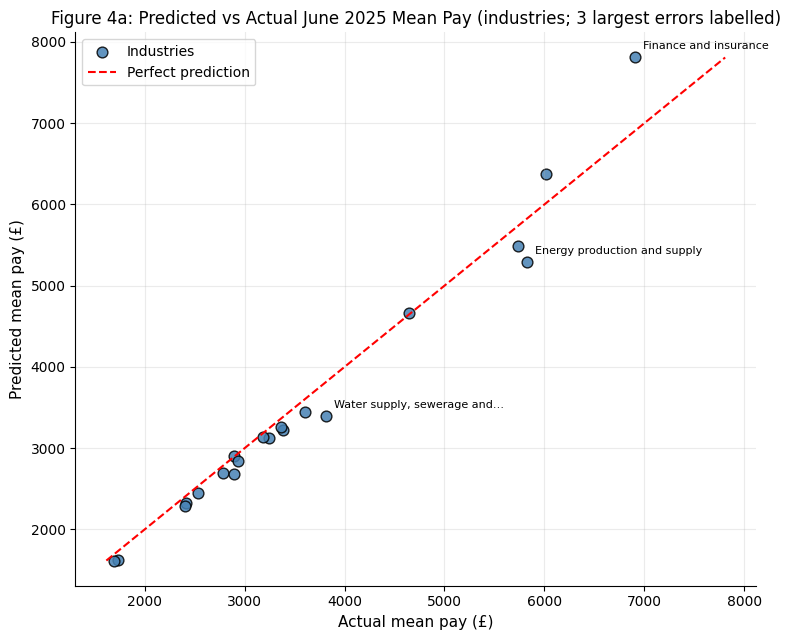

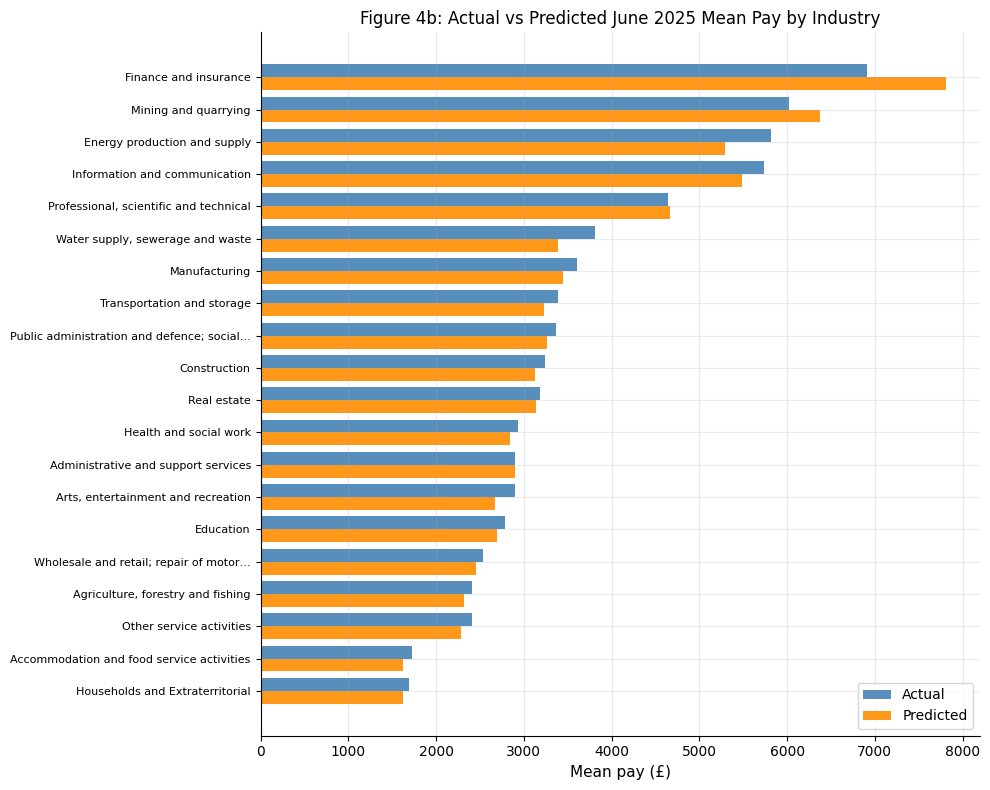

In [10]:
# Figure 4a – predicted vs actual
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(sector_df["Actual"], sector_df["Predicted"], color="steelblue",
           edgecolors="black", s=60, alpha=0.85, label="Industries")
lo = min(sector_df["Actual"].min(), sector_df["Predicted"].min())
hi = max(sector_df["Actual"].max(), sector_df["Predicted"].max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect prediction")
for _, r in sector_df.nlargest(3, "Abs_Error").iterrows():
    ax.annotate(short(r["Industry"], 28), (r["Actual"], r["Predicted"]),
                xytext=(6, 6), textcoords="offset points", fontsize=8)
ax.set(title=f"Figure 4a: Predicted vs Actual {TEST_DATE:%B %Y} Mean Pay (industries; 3 largest errors labelled)",
       xlabel="Actual mean pay (£)", ylabel="Predicted mean pay (£)")
ax.legend()
finish(fig, "figure4a_scatter.png")

# Figure 4b – actual vs predicted by industry
plot_df = sector_df.sort_values("Actual").reset_index(drop=True)
y, h = np.arange(len(plot_df)), 0.4
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y + h / 2, plot_df["Actual"], h, label="Actual", color="steelblue", alpha=0.9)
ax.barh(y - h / 2, plot_df["Predicted"], h, label="Predicted", color="darkorange", alpha=0.9)
ax.set_yticks(y)
ax.set_yticklabels([short(n, 45) for n in plot_df["Industry"]], fontsize=8)
ax.set(title=f"Figure 4b: Actual vs Predicted {TEST_DATE:%B %Y} Mean Pay by Industry", xlabel="Mean pay (£)")
ax.legend(loc="lower right")
finish(fig, "figure4b_barchart.png")

### 4.3 Extension – is one test month enough? (backtest and baselines)
A single test month can flatter or punish a model by luck, and it makes R² impossible to compute.
Here every model is scored on **one-step-ahead forecasts for each of the last 12 months**
(each forecast uses only data before that month). Two things are compared with the brief's model
(linear trend on the full history):

* a **naive baseline** that repeats last month's value, and
* the **same linear regression fitted on a shorter, more recent window** (36 or 12 months), since pay
  growth has not been constant over the whole period.

This section goes beyond the brief, so keep it or drop it as you see fit.

Backtest: one-step-ahead forecasts for the last 12 months (Jul 2024 – Jun 2025)


,Industry MAE (£),Industry MAPE (%),UK MAE (£),UK R²
Naive (last month),166.775,3.559,99.083,0.122
Linear – last 36 months,236.039,4.469,134.315,0.066
Linear – full history (brief),246.301,5.510,144.242,-0.482
Linear – last 12 months,316.468,5.984,195.299,-0.657


Lowest industry-level MAE: Naive (last month)


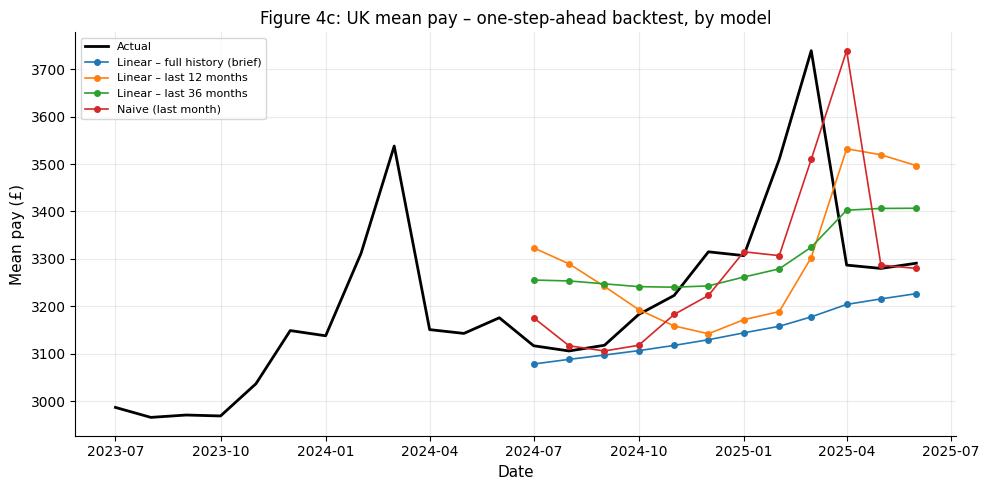

In [11]:
BACKTEST_MONTHS = 12
backtest_dates = pay_t.columns[-BACKTEST_MONTHS:]

MODELS = {
    "Naive (last month)":            lambda s, d: naive_forecast(s, d),
    "Linear – full history (brief)": lambda s, d: linear_forecast(s, d),
    "Linear – last 36 months":       lambda s, d: linear_forecast(s, d, window=36),
    "Linear – last 12 months":       lambda s, d: linear_forecast(s, d, window=12),
}

records = [(model, industry, d, float(s.loc[d]), forecaster(s, d))
           for model, forecaster in MODELS.items()
           for industry, s in pay_t.iterrows()
           for d in backtest_dates]
bt = pd.DataFrame(records, columns=["model", "industry", "date", "actual", "pred"])
bt["abs_err"] = (bt["pred"] - bt["actual"]).abs()
bt["pct_err"] = 100 * bt["abs_err"] / bt["actual"]

sec_bt, uk_bt = bt[bt["industry"] != "UK"], bt[bt["industry"] == "UK"]
summary = pd.DataFrame({
    "Industry MAE (£)":  sec_bt.groupby("model")["abs_err"].mean(),
    "Industry MAPE (%)": sec_bt.groupby("model")["pct_err"].mean(),
    "UK MAE (£)":        uk_bt.groupby("model")["abs_err"].mean(),
    "UK R²":             pd.Series({m: r2_score(g["actual"], g["pred"]) for m, g in uk_bt.groupby("model")}),
}).round(3).sort_values("Industry MAE (£)")

print(f"Backtest: one-step-ahead forecasts for the last {BACKTEST_MONTHS} months "
      f"({backtest_dates[0]:%b %Y} – {backtest_dates[-1]:%b %Y})")
display(summary)
print("Lowest industry-level MAE:", summary.index[0])

# Figure 4c – UK backtest
fig, ax = plt.subplots(figsize=(10, 5))
hist = uk[uk.index >= backtest_dates[0] - pd.DateOffset(months=12)]
ax.plot(hist.index, hist, color="black", lw=2, label="Actual")
for model, g in uk_bt.groupby("model"):
    ax.plot(g["date"], g["pred"], marker="o", ms=4, lw=1.2, label=model)
ax.set(title="Figure 4c: UK mean pay – one-step-ahead backtest, by model", xlabel="Date", ylabel="Mean pay (£)")
ax.legend(fontsize=8)
finish(fig, "figure4c_backtest.png")

**Reading the backtest.** Over the last 12 months the naive "repeat last month" baseline has the lowest industry-level error (MAE ≈ £167), ahead of linear regression on the last 36 months (≈ £236) and on the full history (≈ £246, the model specified in the brief). The full-history and 12-month models also have a negative R² for the UK series, meaning they do worse than simply predicting the average of the backtest window. A single straight line fitted from 2014 onward struggles to follow changes in the pace of pay growth, so the June 2025 forecasts are a fair application of the method but should be described as a limitation, not a strong forecast.

## 5. Unsupervised Learning: K-Means Clustering

**Brief:** use column **V** of the Employees sheet and column **X** of the Mean Pay sheet, save them as
`Employees_PAYE.csv`, and cluster the first 50 observations.

Column letters are converted to positions with `column_index_from_string`, so the choice is explicit and
checked rather than hard-coded as `21` and `23`.

In [12]:
EMP_COL_V = column_index_from_string("V") - 1    # 21
PAY_COL_X = column_index_from_string("X") - 1    # 23
emp_col, pay_col = emp.columns[EMP_COL_V], pay.columns[PAY_COL_X]
print(f"Employees column V -> '{emp_col}'   |   Mean Pay column X -> '{pay_col}'")

cluster_df = (
    emp_proc[["Date", emp_col]].rename(columns={emp_col: "Employees"})
    .merge(pay_proc[["Date", pay_col]].rename(columns={pay_col: "PAYE"}), on="Date")
)
cluster_df[["Employees", "PAYE"]].to_csv("Employees_PAYE.csv", index=False)
print(f"Combined dataset: {cluster_df.shape} | missing values: "
      f"{cluster_df[['Employees', 'PAYE']].isna().sum().to_dict()} | saved Employees_PAYE.csv")

FEATURES = ["Employees", "PAYE"]
sample = cluster_df.iloc[:N_CLUSTER_OBS].dropna().copy()
print(f"Clustering sample: {len(sample)} observations, {sample['Date'].min():%b %Y} – {sample['Date'].max():%b %Y}")
print(f"Correlation between the two features: r = {sample['Employees'].corr(sample['PAYE']):.3f}")
display(sample.head())

Employees column V -> 'UK'   |   Mean Pay column X -> 'UK'
Combined dataset: (132, 3) | missing values: {'Employees': 0, 'PAYE': 0} | saved Employees_PAYE.csv
Clustering sample: 50 observations, Jul 2014 – Aug 2018
Correlation between the two features: r = 0.504


,Date,Employees,PAYE
0,2014-07-01,26893849,2151
1,2014-08-01,26865396,2141
2,2014-09-01,26945380,2134
3,2014-10-01,26965178,2133
4,2014-11-01,27159526,2159


### Choosing k
Both features are standardised first (K-means is distance based). The elbow method and silhouette scores
are then compared. The table also shows the size of the smallest cluster, so that a claim like "k = 5 gives
clusters too small to interpret" can be checked instead of assumed.

,inertia,silhouette,smallest_cluster
k,,,
1,100.0000,NaN,50
2,48.6140,0.4364,21
3,31.8738,0.4391,6
4,20.5396,0.4434,6
5,14.7101,0.4735,3
6,11.5498,0.4166,3
7,9.4052,0.4195,3
8,7.3244,0.4523,3
9,5.9900,0.4577,2


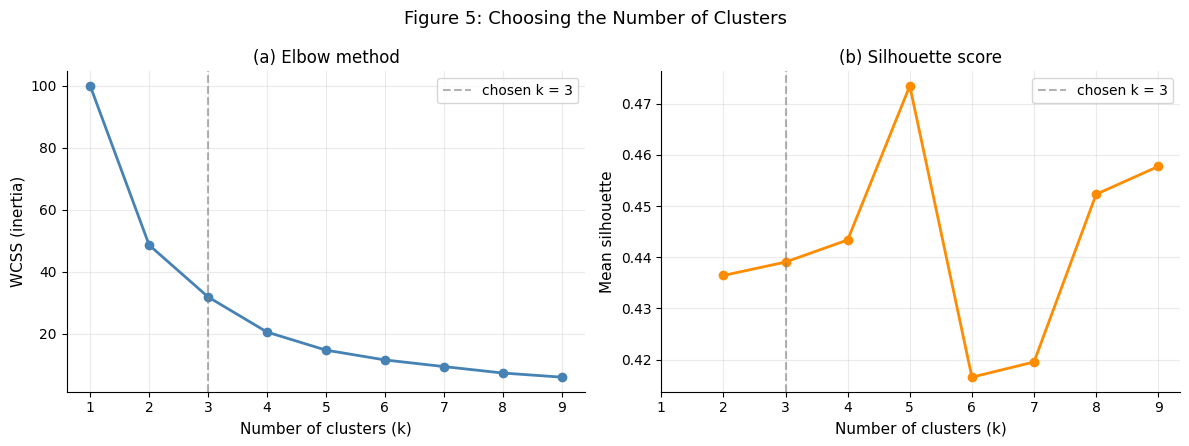

Elbow heuristic suggests k = 3; silhouette is highest at k = 5 (0.4735).
Chosen k = 3: silhouette 0.4391, smallest cluster 6 points.
Moving to k = 5 would raise the silhouette by 0.034 and give a smallest cluster of 3 points.


In [13]:
scaler = StandardScaler().fit(sample[FEATURES])
X = scaler.transform(sample[FEATURES])

rows = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X, km.labels_) if k > 1 else np.nan,
                 "smallest_cluster": int(np.bincount(km.labels_).min())})
k_table = pd.DataFrame(rows).set_index("k")


def elbow_k(inertia):
    """Elbow = point furthest below the straight line joining the first and last inertia values."""
    ks = np.array(inertia.index, dtype=float)
    x = (ks - ks.min()) / (ks.max() - ks.min())
    y = (inertia.to_numpy() - inertia.min()) / (inertia.max() - inertia.min())
    return int(ks[np.argmax(np.abs(x + y - 1))])


k_elbow = elbow_k(k_table["inertia"])
k_sil   = int(k_table["silhouette"].idxmax())

display(k_table.round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(k_table.index, k_table["inertia"], "o-", color="steelblue", lw=2)
ax1.set(title="(a) Elbow method", xlabel="Number of clusters (k)", ylabel="WCSS (inertia)")
ax2.plot(k_table.index[1:], k_table["silhouette"][1:], "o-", color="darkorange", lw=2)
ax2.set(title="(b) Silhouette score", xlabel="Number of clusters (k)", ylabel="Mean silhouette")
for ax in (ax1, ax2):
    ax.axvline(K_FINAL, color="grey", ls="--", alpha=0.6, label=f"chosen k = {K_FINAL}")
    ax.set_xticks(k_table.index)
    ax.legend()
fig.suptitle("Figure 5: Choosing the Number of Clusters", fontsize=13)
finish(fig, "figure5_elbow.png")

print(f"Elbow heuristic suggests k = {k_elbow}; silhouette is highest at k = {k_sil} "
      f"({k_table.loc[k_sil, 'silhouette']:.4f}).")
print(f"Chosen k = {K_FINAL}: silhouette {k_table.loc[K_FINAL, 'silhouette']:.4f}, "
      f"smallest cluster {k_table.loc[K_FINAL, 'smallest_cluster']} points.")
print(f"Moving to k = {k_sil} would raise the silhouette by {k_table.loc[k_sil, 'silhouette'] - k_table.loc[K_FINAL, 'silhouette']:.3f} "
      f"and give a smallest cluster of {k_table.loc[k_sil, 'smallest_cluster']} points.")

**Decision rule.** Prefer the elbow value of k unless another k has a *clearly* higher silhouette score
(roughly 0.05 or more) **and** its smallest cluster is still big enough to describe. Compare the numbers printed
above against that rule and write your justification from them. If they point somewhere other than `K_FINAL`,
change `K_FINAL` in the setup cell and everything below updates.

**Applied to this data.** The elbow heuristic points to k = 3. Silhouette is highest at k = 5 (0.4735) but only 0.034 above k = 3 (0.4391), below the 0.05 threshold, and k = 5 would leave a cluster of just 3 points (the smallest cluster at k = 3 has 6). By the rule above, k = 3 stands.

### Final model

In [14]:
km = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE).fit(X)

# K-means labels are arbitrary, so renumber them by the size of the Employees centroid
# (cluster 0 = lowest employees). This keeps colours and labels meaningful.
order = np.argsort(km.cluster_centers_[:, 0])
relabel = {old: new for new, old in enumerate(order)}
sample["Cluster"] = [relabel[l] for l in km.labels_]
centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_[order]), columns=FEATURES)

profile = (sample.groupby("Cluster")
           .agg(n=("Date", "size"), mean_employees=("Employees", "mean"), mean_paye=("PAYE", "mean"),
                first_date=("Date", "min"), last_date=("Date", "max")))
print("Cluster profiles (clusters ordered by mean Employees):")
display(profile.round({"mean_employees": 1, "mean_paye": 1}))

# Are the clusters just consecutive blocks of time?
changes = int((sample.sort_values("Date")["Cluster"].diff().fillna(0) != 0).sum())
contiguous = changes == K_FINAL - 1
print(f"Cluster changes along the time axis: {changes} "
      f"({'clusters are consecutive time blocks' if contiguous else 'clusters interleave in time'}).")

Cluster profiles (clusters ordered by mean Employees):


,n,mean_employees,mean_paye,first_date,last_date
Cluster,,,,,
0,20,27377191.3,2200.9,2014-07-01,2016-05-01
1,6,27923939.5,2497.2,2015-03-01,2018-03-01
2,24,28294505.8,2304.0,2016-02-01,2018-08-01


Cluster changes along the time axis: 10 (clusters interleave in time).


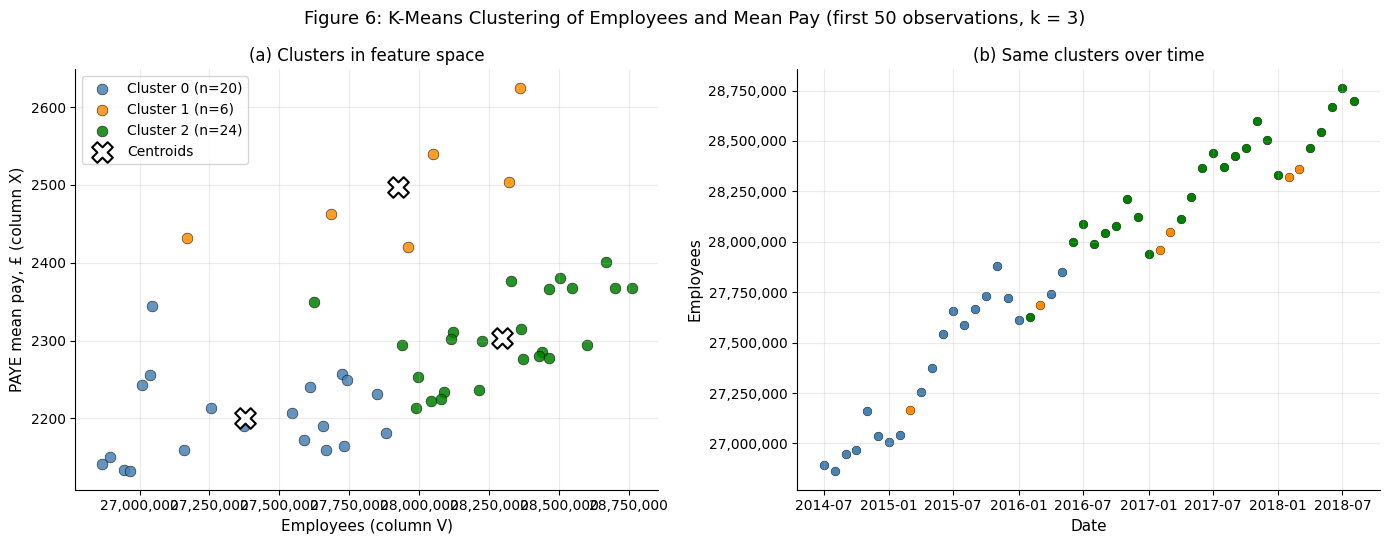

In [15]:
palette = ["steelblue", "darkorange", "green", "crimson", "purple", "brown", "teal", "olive", "black"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
for c in range(K_FINAL):
    sub = sample[sample["Cluster"] == c]
    ax1.scatter(sub["Employees"], sub["PAYE"], color=palette[c], s=60, edgecolors="black",
                linewidths=0.4, alpha=0.85, label=f"Cluster {c} (n={len(sub)})")
    ax2.scatter(sub["Date"], sub["Employees"], color=palette[c], s=40, edgecolors="black", linewidths=0.3)
ax1.scatter(centroids["Employees"], centroids["PAYE"], marker="X", s=220, color="white",
            edgecolors="black", linewidths=1.5, label="Centroids", zorder=5)
ax1.xaxis.set_major_formatter(thousands)
ax2.yaxis.set_major_formatter(thousands)
ax1.set(title="(a) Clusters in feature space", xlabel="Employees (column V)", ylabel="PAYE mean pay, £ (column X)")
ax2.set(title="(b) Same clusters over time", xlabel="Date", ylabel="Employees")
ax1.legend()
fig.suptitle(f"Figure 6: K-Means Clustering of Employees and Mean Pay "
             f"(first {len(sample)} observations, k = {K_FINAL})", fontsize=13)
finish(fig, "figure6_clustering.png")

**Reading Figure 6.** In this data the two features are only moderately correlated (r = 0.504 over the 50 observations), and the clusters are *not* consecutive blocks of time: the cluster label changes 10 times along the time axis (see the profile table above). Clusters 0 and 2 roughly split the earlier and later months (Jul 2014 – May 2016 vs Feb 2016 – Aug 2018) and differ mainly in employee count. Cluster 1 is a small group (n = 6) with noticeably higher mean pay (about £2,500 vs £2,200–£2,300) at mid-range employee counts, scattered between 2015 and 2018. Describe the clusters using the profile numbers rather than assumptions about specific events.

## 6. Summary of results
Every figure below is generated from the analysis above.

In [16]:
print("=" * 64)
print("SUMMARY")
print("=" * 64)

print("\nData")
print(f"  {len(emp)} employee rows, {len(pay)} pay rows, {pay['Date'].min():%b %Y} – {pay['Date'].max():%b %Y}")

print("\nTask 2 – EDA")
print(f"  UK employees {growth_pct:+.1%} over the period; COVID dip {dip_pct:+.1%} at {trough_date:%b %Y}")
print(f"  Top-3 vs bottom-3 pay gap: £{gap_2021:,.0f} (2021) -> £{gap_latest:,.0f} (last 12 months)")

print("\nTask 3 – Pre-processing")
print(f"  Missing values before/after forward-fill: {sum(missing_before.values())} -> {sum(missing_after.values())}")
z_ok = bool(np.allclose(table3["Mean (after)"], 0, atol=1e-3) and np.allclose(table3["Std dev (after)"], 1, atol=1e-3))
print(f"  Z-score standardisation: mean 0 and std 1 achieved for UK employees and UK pay: {z_ok}")

print(f"\nTask 4 – Linear regression ({TEST_DATE:%b %Y})")
print(f"  UK: actual £{actual_uk:,.2f}, predicted £{pred_uk:,.2f}, abs error £{abs_err_uk:,.2f}")
print(f"  {len(sector_df)} industries: MAE £{mae_sectors:,.2f}, RMSE £{rmse_sectors:,.2f}")
print(f"  Backtest ({BACKTEST_MONTHS} months): lowest industry MAE = {summary.index[0]} "
      f"(£{summary['Industry MAE (£)'].iloc[0]:,.2f})")

print("\nTask 5 – K-means")
print(f"  Column V = '{emp_col}', column X = '{pay_col}', {len(sample)} observations")
print(f"  Chosen k = {K_FINAL} (elbow heuristic: {k_elbow}, best silhouette: k = {k_sil})")
print(f"  Silhouette at k = {K_FINAL}: {k_table.loc[K_FINAL, 'silhouette']:.4f}")

SUMMARY

Data
  133 employee rows, 132 pay rows, Jul 2014 – Jun 2025

Task 2 – EDA
  UK employees +13.1% over the period; COVID dip -2.4% at Dec 2020
  Top-3 vs bottom-3 pay gap: £3,785 (2021) -> £4,396 (last 12 months)

Task 3 – Pre-processing
  Missing values before/after forward-fill: 22 -> 0
  Z-score standardisation: mean 0 and std 1 achieved for UK employees and UK pay: True

Task 4 – Linear regression (Jun 2025)
  UK: actual £3,291.00, predicted £3,226.85, abs error £64.15
  20 industries: MAE £196.64, RMSE £286.40
  Backtest (12 months): lowest industry MAE = Naive (last month) (£166.78)

Task 5 – K-means
  Column V = 'UK', column X = 'UK', 50 observations
  Chosen k = 3 (elbow heuristic: 3, best silhouette: k = 5)
  Silhouette at k = 3: 0.4391
